In [2]:
# ============================================================
# Cell 1: Import Required Libraries
# Purpose: Import libraries required for model training
# ============================================================

import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel

from sklearn.metrics import accuracy_score, f1_score

from tqdm.auto import tqdm

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.13.0+cu126
CUDA available: True


In [3]:
# ============================================================
# Cell 2: Set Random Seeds and Device
# Purpose: Ensure reproducibility and select GPU/CPU
# ============================================================

import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 3050


In [4]:
# ============================================================
# Cell 3: Load Training and Validation Data
# Purpose: Load the processed datasets created in Notebook 1
# ============================================================

PROJECT_ROOT = "/mnt/g/banglafake-detection"
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

train_path = os.path.join(PROCESSED_DIR, "train.csv")
validation_path = os.path.join(PROCESSED_DIR, "validation.csv")

train_df = pd.read_csv(train_path)
validation_df = pd.read_csv(validation_path)

print("Train dataset shape:", train_df.shape)
print("Validation dataset shape:", validation_df.shape)

print("\nTrain label distribution:")
print(train_df["label"].value_counts())

print("\nValidation label distribution:")
print(validation_df["label"].value_counts())

Train dataset shape: (2790, 3)
Validation dataset shape: (598, 3)

Train label distribution:
label
1    1397
0    1393
Name: count, dtype: int64

Validation label distribution:
label
1    300
0    298
Name: count, dtype: int64


In [5]:
# ============================================================
# Cell 4: Load BanglaBERT Tokenizer
# Purpose: Convert Bangla text into tokens for BanglaBERT
# ============================================================

from transformers import AutoTokenizer

MODEL_NAME = "csebuetnlp/banglabert"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully!")
print("Model:", MODEL_NAME)

Tokenizer loaded successfully!
Model: csebuetnlp/banglabert


In [6]:
# ============================================================
# Cell 5: Test BanglaBERT Tokenization
# Purpose: Verify that Bangla text is correctly tokenized
# ============================================================

sample_text = train_df["text"].iloc[0]

encoding = tokenizer(
    sample_text,
    truncation=True,
    padding="max_length",
    max_length=256,
    return_tensors="pt"
)

print("Original text:")
print(sample_text[:300])

print("\nInput IDs shape:")
print(encoding["input_ids"].shape)

print("\nAttention mask shape:")
print(encoding["attention_mask"].shape)

print("\nNumber of tokens:")
print(int(encoding["attention_mask"].sum()))

Original text:
বড় হচ্ছে ভূ‑পর্যবেক্ষণ প্রযুক্তি বাজার সারা বিশ্বেই ভূ‑পর্যবেক্ষণ প্রযুক্তির চাহিদা বাড়ছে। বড় দেশগুলো তো বটেই উদীয়মান দেশগুলোও এ খাতে তাদের বিনিয়োগ বাড়াচ্ছে। এরই মধ্যে এই প্রযুক্তির বাজার ৫০০ কোটি মার্কিন ডলার ছুঁয়েছে। এটি আগামী ২০৩৩ সালের মধ্যে ৮০০ কোটি ডলার ছাড়িয়ে যাবে বলে জানিয়েছে মহাকাশ প্রযুক্ত

Input IDs shape:
torch.Size([1, 256])

Attention mask shape:
torch.Size([1, 256])

Number of tokens:
256


In [7]:
# ============================================================
# Cell 6: Create Bangla News Dataset Class
# Purpose: Convert Bangla news text into PyTorch tensors
# ============================================================

class BanglaFakeNewsDataset(Dataset):
    
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        text = str(self.dataframe.loc[idx, "text"])
        label = int(self.dataframe.loc[idx, "label"])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

print("Dataset class created successfully!")

Dataset class created successfully!


In [8]:
# ============================================================
# Cell 7: Create Train & Validation Dataset
# Purpose: Prepare datasets for model training and validation
# ============================================================

MAX_LENGTH = 256

train_dataset = BanglaFakeNewsDataset(
    dataframe=train_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

validation_dataset = BanglaFakeNewsDataset(
    dataframe=validation_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(validation_dataset))

Train dataset size: 2790
Validation dataset size: 598


In [9]:
# ============================================================
# Cell 8: Create DataLoaders
# Purpose: Load training and validation data in mini-batches
# ============================================================

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Batch size:", BATCH_SIZE)

Train batches: 349
Validation batches: 75
Batch size: 8


In [10]:
# ============================================================
# Cell 9: Check Training Batch
# Purpose: Verify DataLoader output shapes and data types
# ============================================================

batch = next(iter(train_loader))

print("Input IDs shape:", batch["input_ids"].shape)
print("Attention mask shape:", batch["attention_mask"].shape)
print("Labels shape:", batch["label"].shape)

print("\nInput IDs dtype:", batch["input_ids"].dtype)
print("Attention mask dtype:", batch["attention_mask"].dtype)
print("Labels dtype:", batch["label"].dtype)

print("\nLabels in batch:", batch["label"].tolist())

Input IDs shape: torch.Size([8, 256])
Attention mask shape: torch.Size([8, 256])
Labels shape: torch.Size([8])

Input IDs dtype: torch.int64
Attention mask dtype: torch.int64
Labels dtype: torch.int64

Labels in batch: [1, 0, 0, 0, 1, 0, 0, 1]


In [11]:
# ============================================================
# Cell 10: Load BanglaBERT Backbone
# Purpose: Load pretrained BanglaBERT for contextual embeddings
# ============================================================

from transformers import AutoModel

MODEL_NAME = "csebuetnlp/banglabert"

banglabert = AutoModel.from_pretrained(MODEL_NAME)

banglabert.to(device)

print("BanglaBERT loaded successfully!")
print("Model:", MODEL_NAME)

BanglaBERT loaded successfully!
Model: csebuetnlp/banglabert


In [12]:
# ============================================================
# Cell 11: Test BanglaBERT Output
# Purpose: Verify contextual embedding dimensions
# ============================================================

banglabert.eval()

with torch.no_grad():
    sample_input_ids = batch["input_ids"].to(device)
    sample_attention_mask = batch["attention_mask"].to(device)

    bert_output = banglabert(
        input_ids=sample_input_ids,
        attention_mask=sample_attention_mask
    )

print("Last hidden state shape:")
print(bert_output.last_hidden_state.shape)

print("\nBatch size:", bert_output.last_hidden_state.shape[0])
print("Sequence length:", bert_output.last_hidden_state.shape[1])
print("Hidden size:", bert_output.last_hidden_state.shape[2])

Last hidden state shape:
torch.Size([8, 256, 768])

Batch size: 8
Sequence length: 256
Hidden size: 768


In [13]:

# ============================================================
# Cell 12: Define CNN Layer
# Purpose: Extract local patterns from BanglaBERT embeddings
# ============================================================

CNN_CHANNELS = 256
KERNEL_SIZE = 3

cnn = nn.Conv1d(
    in_channels=768,
    out_channels=CNN_CHANNELS,
    kernel_size=KERNEL_SIZE,
    padding=1
).to(device)

print("CNN layer created successfully!")
print("Input channels:", 768)
print("Output channels:", CNN_CHANNELS)
print("Kernel size:", KERNEL_SIZE)

CNN layer created successfully!
Input channels: 768
Output channels: 256
Kernel size: 3


In [14]:
# ============================================================
# Cell 13: Test CNN Output
# Purpose: Pass BanglaBERT embeddings through CNN
# ============================================================

# BanglaBERT output:
# [batch, sequence, hidden] = [8, 256, 768]

bert_embeddings = bert_output.last_hidden_state

# Conv1D expects:
# [batch, channels, sequence]
cnn_input = bert_embeddings.permute(0, 2, 1)

print("Before CNN:", cnn_input.shape)

# Apply CNN
cnn_output = cnn(cnn_input)

# Apply activation
cnn_output = torch.relu(cnn_output)

print("After CNN:", cnn_output.shape)

Before CNN: torch.Size([8, 768, 256])
After CNN: torch.Size([8, 256, 256])


In [15]:
# ============================================================
# Cell 14: Define Attention Layer
# Purpose: Learn which token-level features are important
# ============================================================

ATTENTION_DIM = 128

attention_projection = nn.Linear(
    CNN_CHANNELS,
    ATTENTION_DIM
).to(device)

attention_score = nn.Linear(
    ATTENTION_DIM,
    1
).to(device)

print("Attention layer created successfully!")
print("CNN feature size:", CNN_CHANNELS)
print("Attention dimension:", ATTENTION_DIM)

Attention layer created successfully!
CNN feature size: 256
Attention dimension: 128


In [16]:
# ============================================================
# Cell 15: Calculate Attention Weights
# Purpose: Assign importance weights to each token
# ============================================================

# CNN output shape:
# [batch, channels, sequence]
# [8, 256, 256]

# Convert to:
# [batch, sequence, channels]
attention_input = cnn_output.permute(0, 2, 1)

print("Attention input shape:", attention_input.shape)

# Project CNN features into attention space
attention_hidden = torch.tanh(
    attention_projection(attention_input)
)

print("Attention hidden shape:", attention_hidden.shape)

# Calculate attention scores
attention_scores = attention_score(
    attention_hidden
).squeeze(-1)

print("Attention scores shape:", attention_scores.shape)

# Convert scores into probabilities
attention_weights = torch.softmax(
    attention_scores,
    dim=1
)

print("Attention weights shape:", attention_weights.shape)

# Check that weights sum to 1 for each sample
weight_sum = attention_weights.sum(dim=1)

print("Attention weight sum for first sample:",
      weight_sum[0].item())

Attention input shape: torch.Size([8, 256, 256])
Attention hidden shape: torch.Size([8, 256, 128])
Attention scores shape: torch.Size([8, 256])
Attention weights shape: torch.Size([8, 256])
Attention weight sum for first sample: 1.0


In [17]:
# ============================================================
# Cell 16: Create Attention Context Vector
# Purpose: Combine token features using learned attention weights
# ============================================================

# Expand attention weights:
# [batch, sequence] → [batch, sequence, 1]

attention_weights_expanded = attention_weights.unsqueeze(-1)

# Weighted CNN features
weighted_features = (
    attention_input * attention_weights_expanded
)

print("Weighted features shape:", weighted_features.shape)

# Sum across the sequence dimension
attention_context = weighted_features.sum(dim=1)

print("Attention context shape:", attention_context.shape)

Weighted features shape: torch.Size([8, 256, 256])
Attention context shape: torch.Size([8, 256])


In [18]:
# ============================================================
# Cell 17: Define Classification Head
# Purpose: Map the attention context vector to Fake/Real classes
# ============================================================

classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(CNN_CHANNELS, 2)
).to(device)

print("Classification head created successfully!")
print("Input features:", CNN_CHANNELS)
print("Output classes:", 2)

Classification head created successfully!
Input features: 256
Output classes: 2


In [19]:
# ============================================================
# Cell 18: Define Unified BanglaBERT + CNN + Attention Model
# Purpose: Combine BERT, CNN, attention, and classifier into
#          one trainable PyTorch model with padding-aware attention
# ============================================================

class BanglaBERTCNNWithAttention(nn.Module):

    def __init__(
        self,
        model_name,
        cnn_channels=256,
        kernel_size=3,
        attention_dim=128,
        num_classes=2,
        dropout=0.3
    ):
        super().__init__()

        # BanglaBERT backbone
        self.bert = AutoModel.from_pretrained(model_name)

        # CNN for local token-level feature extraction
        self.cnn = nn.Conv1d(
            in_channels=self.bert.config.hidden_size,
            out_channels=cnn_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        # Attention projection
        self.attention_projection = nn.Linear(
            cnn_channels,
            attention_dim
        )

        # Attention score
        self.attention_score = nn.Linear(
            attention_dim,
            1
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(cnn_channels, num_classes)
        )

    def forward(self, input_ids, attention_mask):

        # 1. BERT contextual embeddings
        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        x = bert_output.last_hidden_state

        # 2. Mask padding embeddings before CNN
        mask = attention_mask.unsqueeze(-1).float()
        x = x * mask

        # 3. CNN expects [batch, channels, sequence]
        x = x.permute(0, 2, 1)

        x = torch.relu(self.cnn(x))

        # 4. Back to [batch, sequence, features]
        x = x.permute(0, 2, 1)

        # 5. Calculate attention scores
        attention_hidden = torch.tanh(
            self.attention_projection(x)
        )

        attention_scores = self.attention_score(
            attention_hidden
        ).squeeze(-1)

        # 6. Ignore padding tokens during attention
        attention_scores = attention_scores.masked_fill(
            attention_mask == 0,
            -1e9
        )

        # 7. Normalize attention weights
        attention_weights = torch.softmax(
            attention_scores,
            dim=1
        )

        # 8. Attention-weighted context vector
        attention_context = torch.sum(
            x * attention_weights.unsqueeze(-1),
            dim=1
        )

        # 9. Final classification
        logits = self.classifier(attention_context)

        return logits


print("Unified model class created successfully!")

Unified model class created successfully!


In [20]:
# ============================================================
# Cell 19: Initialize Unified Model
# Purpose: Create the complete BanglaBERT + CNN + Attention model
#          and move it to the selected device
# ============================================================

model = BanglaBERTCNNWithAttention(
    model_name=MODEL_NAME,
    cnn_channels=CNN_CHANNELS,
    kernel_size=KERNEL_SIZE,
    attention_dim=ATTENTION_DIM,
    num_classes=2,
    dropout=0.3
).to(device)

print("Unified model initialized successfully!")
print("Device:", device)

Unified model initialized successfully!
Device: cuda


In [21]:
# ============================================================
# Cell 20: Check Trainable Parameters
# Purpose: Verify that all model components are trainable
# ============================================================

total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(
    f"Trainable percentage: "
    f"{100 * trainable_params / total_params:.2f}%"
)

Total parameters: 110,650,371
Trainable parameters: 110,650,371
Trainable percentage: 100.00%


In [22]:
# ============================================================
# Cell 21: Test Complete Model Forward Pass
# Purpose: Verify that the unified model produces valid
#          classification logits
# ============================================================

model.eval()

with torch.no_grad():
    sample_input_ids = batch["input_ids"].to(device)
    sample_attention_mask = batch["attention_mask"].to(device)

    logits = model(
        input_ids=sample_input_ids,
        attention_mask=sample_attention_mask
    )

print("Logits shape:", logits.shape)
print("Expected shape:", (BATCH_SIZE, 2))
print("Sample logits:")
print(logits[:2])

Logits shape: torch.Size([8, 2])
Expected shape: (8, 2)
Sample logits:
tensor([[-0.1033, -0.0280],
        [-0.0896, -0.0295]], device='cuda:0')


In [23]:
# ============================================================
# Cell 22: Define Loss Function and Optimizer
# Purpose: Configure the objective function and optimizer
#          for model training
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", 2e-5)
print("Weight decay:", 0.01)

Loss function: CrossEntropyLoss()
Optimizer: AdamW
Learning rate: 2e-05
Weight decay: 0.01


In [24]:
# ============================================================
# Cell 23: Define Training Function
# Purpose: Train the model for one epoch and calculate
#          training loss and accuracy
# ============================================================

def train_one_epoch(model, data_loader, criterion, optimizer, device):

    model.train()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    progress_bar = tqdm(
        data_loader,
        desc="Training",
        leave=False
    )

    for batch in progress_bar:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    average_loss = total_loss / len(data_loader)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    f1 = f1_score(
        all_labels,
        all_predictions
    )

    return average_loss, accuracy, f1


print("Training function created successfully!")

Training function created successfully!


In [25]:
# ============================================================
# Cell 24: Define Validation Function
# Purpose: Evaluate model performance on the validation set
#          without updating model parameters
# ============================================================

def validate_one_epoch(model, data_loader, criterion, device):

    model.eval()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():

        progress_bar = tqdm(
            data_loader,
            desc="Validation",
            leave=False
        )

        for batch in progress_bar:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(logits, labels)

            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    average_loss = total_loss / len(data_loader)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    f1 = f1_score(
        all_labels,
        all_predictions
    )

    return average_loss, accuracy, f1


print("Validation function created successfully!")

Validation function created successfully!


In [26]:
# ============================================================
# Cell 25: Set Training Configuration
# Purpose: Define the number of training epochs and initialize
#          storage for tracking training and validation metrics
# ============================================================

NUM_EPOCHS = 3

history = {
    "train_loss": [],
    "train_accuracy": [],
    "train_f1": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_f1": []
}

print("Number of epochs:", NUM_EPOCHS)
print("Training history initialized successfully!")

Number of epochs: 3
Training history initialized successfully!


In [27]:
# ============================================================
# Cell 26: Train the Model
# Purpose: Train for multiple epochs, monitor validation
#          performance, and save the best model by F1 score
# ============================================================

BEST_MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "models",
    "best_banglabert_cnn_attention.pt"
)

best_val_f1 = 0.0

for epoch in range(NUM_EPOCHS):

    print(f"\n{'=' * 60}")
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print(f"{'=' * 60}")

    train_loss, train_accuracy, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy, val_f1 = validate_one_epoch(
        model,
        validation_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["train_f1"].append(train_f1)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["val_f1"].append(val_f1)

    print(f"\nTrain Loss:      {train_loss:.4f}")
    print(f"Train Accuracy:  {train_accuracy:.4f}")
    print(f"Train F1:        {train_f1:.4f}")

    print(f"Val Loss:        {val_loss:.4f}")
    print(f"Val Accuracy:    {val_accuracy:.4f}")
    print(f"Val F1:          {val_f1:.4f}")

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "model_name": MODEL_NAME,
                "max_length": MAX_LENGTH,
                "cnn_channels": CNN_CHANNELS,
                "kernel_size": KERNEL_SIZE,
                "attention_dim": ATTENTION_DIM,
                "num_classes": 2,
                "best_val_f1": best_val_f1
            },
            BEST_MODEL_PATH
        )

        print(f"\nBest model saved!")
        print(f"Best validation F1: {best_val_f1:.4f}")

print("\nTraining completed!")
print("Best validation F1:", f"{best_val_f1:.4f}")
print("Model path:", BEST_MODEL_PATH)


Epoch 1/3


Training:   0%|          | 0/349 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]


Train Loss:      0.1846
Train Accuracy:  0.9384
Train F1:        0.9391
Val Loss:        0.0601
Val Accuracy:    0.9849
Val F1:          0.9849

Best model saved!
Best validation F1: 0.9849

Epoch 2/3


Training:   0%|          | 0/349 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]


Train Loss:      0.0698
Train Accuracy:  0.9796
Train F1:        0.9798
Val Loss:        0.0559
Val Accuracy:    0.9833
Val F1:          0.9835

Epoch 3/3


Training:   0%|          | 0/349 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]


Train Loss:      0.0438
Train Accuracy:  0.9889
Train F1:        0.9890
Val Loss:        0.0706
Val Accuracy:    0.9799
Val F1:          0.9803

Training completed!
Best validation F1: 0.9849
Model path: /mnt/g/banglafake-detection/models/best_banglabert_cnn_attention.pt


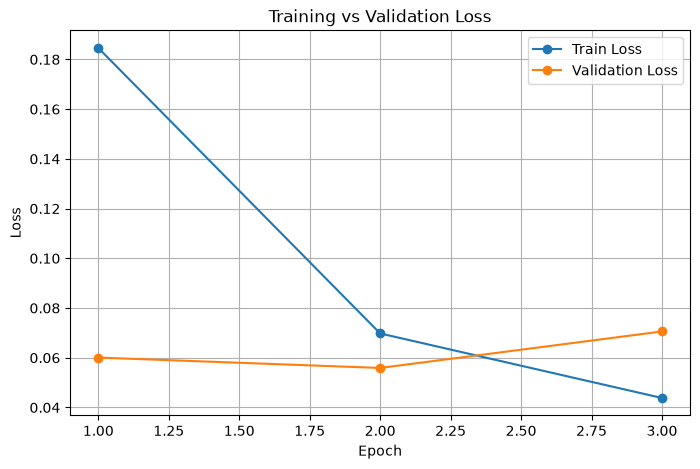

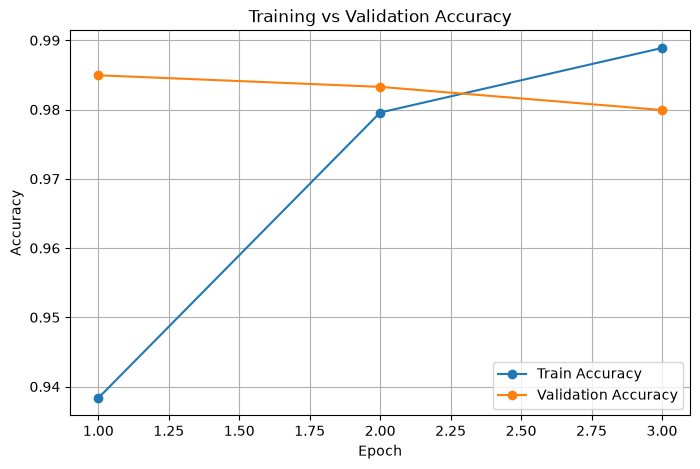

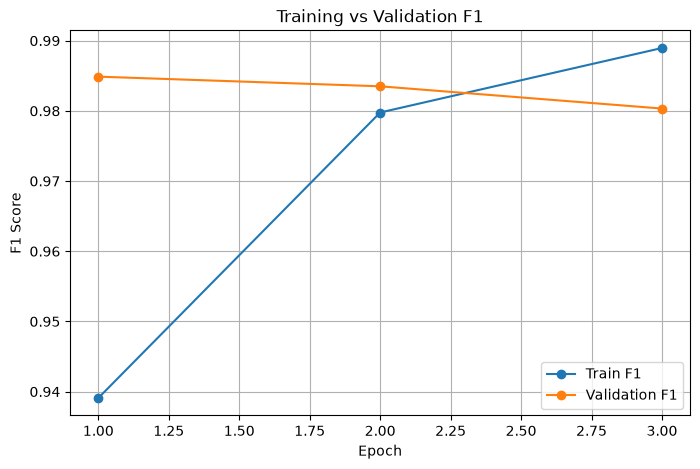

In [28]:
# ============================================================
# Cell 27: Plot Training History
# Purpose: Visualize loss, accuracy, and F1 across epochs
#          to inspect learning behavior and overfitting
# ============================================================

import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_accuracy"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_f1"], marker="o", label="Train F1")
plt.plot(epochs, history["val_f1"], marker="o", label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Training vs Validation F1")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# ============================================================
# Cell 28: Load Best Model Checkpoint
# Purpose: Restore the model weights with the best validation F1
#          before evaluating on the untouched test set
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print("Best model checkpoint loaded successfully!")
print("Best validation F1:", f"{checkpoint['best_val_f1']:.4f}")
print("Model ready for test evaluation.")

Best model checkpoint loaded successfully!
Best validation F1: 0.9849
Model ready for test evaluation.


In [30]:
# ============================================================
# Cell 29: Load Test Dataset
# Purpose: Load the untouched test set for final evaluation
# ============================================================

test_path = os.path.join(
    PROCESSED_DIR,
    "test.csv"
)

test_df = pd.read_csv(test_path)

print("Test dataset shape:", test_df.shape)

print("\nTest label distribution:")
print(test_df["label"].value_counts())

Test dataset shape: (599, 3)

Test label distribution:
label
1    300
0    299
Name: count, dtype: int64


In [31]:
# ============================================================
# Cell 30: Create Test Dataset & DataLoader
# Purpose: Prepare the untouched test set for final evaluation
# ============================================================

test_dataset = BanglaFakeNewsDataset(
    dataframe=test_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Test dataset size:", len(test_dataset))
print("Test batches:", len(test_loader))
print("Batch size:", BATCH_SIZE)

Test dataset size: 599
Test batches: 75
Batch size: 8


In [32]:
# ============================================================
# Cell 31: Run Test Inference
# Purpose: Generate predictions and class probabilities on the
#          untouched test set
# ============================================================

model.eval()

all_test_labels = []
all_test_predictions = []
all_test_probabilities = []

with torch.no_grad():

    progress_bar = tqdm(
        test_loader,
        desc="Test Evaluation",
        leave=False
    )

    for batch in progress_bar:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probabilities = torch.softmax(logits, dim=1)
        predictions = torch.argmax(logits, dim=1)

        all_test_labels.extend(
            labels.cpu().numpy()
        )

        all_test_predictions.extend(
            predictions.cpu().numpy()
        )

        all_test_probabilities.extend(
            probabilities.cpu().numpy()
        )

print("Test inference completed successfully!")
print("Number of test labels:", len(all_test_labels))
print("Number of predictions:", len(all_test_predictions))
print("Number of probability outputs:", len(all_test_probabilities))

Test Evaluation:   0%|          | 0/75 [00:00<?, ?it/s]

Test inference completed successfully!
Number of test labels: 599
Number of predictions: 599
Number of probability outputs: 599


In [33]:
# ============================================================
# Cell 32: Calculate Test Metrics
# Purpose: Calculate final Accuracy, Precision, Recall, and F1
#          on the untouched test set
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_accuracy = accuracy_score(
    all_test_labels,
    all_test_predictions
)

test_precision = precision_score(
    all_test_labels,
    all_test_predictions,
    zero_division=0
)

test_recall = recall_score(
    all_test_labels,
    all_test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    all_test_labels,
    all_test_predictions,
    zero_division=0
)

print("Final Test Results")
print("=" * 40)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")

Final Test Results
Accuracy:  0.9733
Precision: 0.9797
Recall:    0.9667
F1 Score:  0.9732


Confusion Matrix:
[[293   6]
 [ 10 290]]


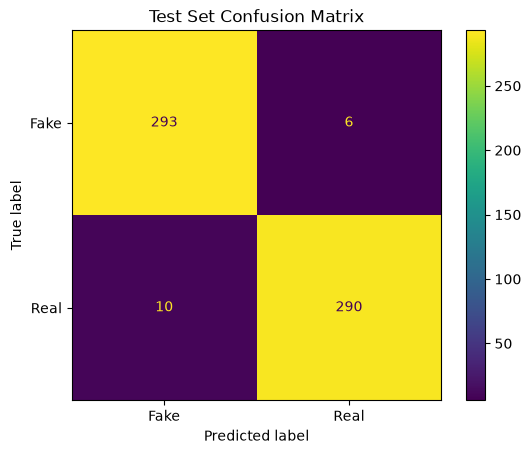

In [34]:
# ============================================================
# Cell 33: Generate Confusion Matrix
# Purpose: Analyze correct and incorrect Fake/Real predictions
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    all_test_labels,
    all_test_predictions
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()
plt.title("Test Set Confusion Matrix")
plt.show()

In [35]:
# ============================================================
# Cell 34: Generate Classification Report
# Purpose: Calculate detailed Fake/Real classification metrics
# ============================================================

from sklearn.metrics import classification_report

report = classification_report(
    all_test_labels,
    all_test_predictions,
    target_names=["Fake", "Real"],
    digits=4,
    zero_division=0
)

print("Test Set Classification Report")
print("=" * 50)
print(report)

Test Set Classification Report
              precision    recall  f1-score   support

        Fake     0.9670    0.9799    0.9734       299
        Real     0.9797    0.9667    0.9732       300

    accuracy                         0.9733       599
   macro avg     0.9734    0.9733    0.9733       599
weighted avg     0.9734    0.9733    0.9733       599



Test ROC-AUC: 0.9926


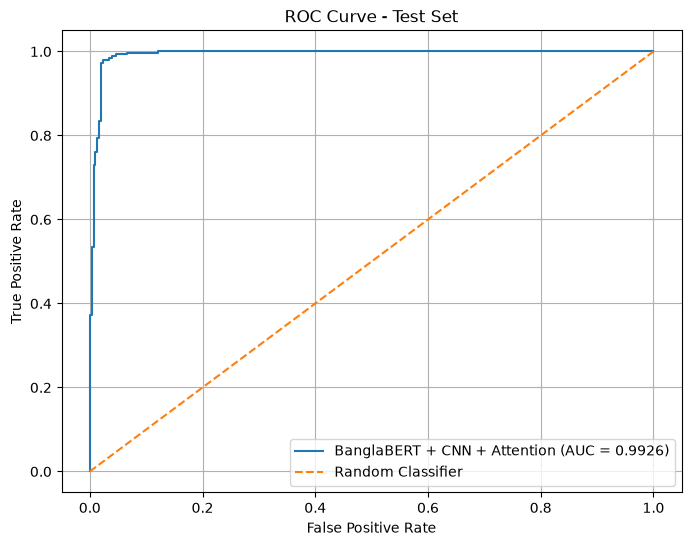

In [36]:
# ============================================================
# Cell 35: Calculate ROC Curve and ROC-AUC
# Purpose: Measure the model's discrimination ability across
#          different classification thresholds
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score

test_probabilities = np.array(all_test_probabilities)[:, 1]

roc_auc = roc_auc_score(
    all_test_labels,
    test_probabilities
)

fpr, tpr, thresholds = roc_curve(
    all_test_labels,
    test_probabilities
)

print(f"Test ROC-AUC: {roc_auc:.4f}")

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"BanglaBERT + CNN + Attention (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
# ============================================================
# Cell 36: Save Final Evaluation Metrics
# Purpose: Store all final test metrics for reporting
# ============================================================

final_metrics = {
    "Accuracy": test_accuracy,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1 Score": test_f1,
    "ROC-AUC": roc_auc
}

metrics_df = pd.DataFrame(
    [final_metrics]
)

metrics_path = os.path.join(
    PROJECT_ROOT,
    "reports",
    "final_test_metrics.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False
)

print("Final metrics saved successfully!")
print("Path:", metrics_path)
print("\nFinal Metrics:")
print(metrics_df.round(4))

Final metrics saved successfully!
Path: /mnt/g/banglafake-detection/reports/final_test_metrics.csv

Final Metrics:
   Accuracy  Precision  Recall  F1 Score  ROC-AUC
0    0.9733     0.9797  0.9667    0.9732   0.9926


In [38]:
# ============================================================
# Cell 37: Save Detailed Classification Report
# Purpose: Save per-class Precision, Recall, and F1 results
#          for the final research report
# ============================================================

report_path = os.path.join(
    PROJECT_ROOT,
    "reports",
    "classification_report.txt"
)

with open(report_path, "w", encoding="utf-8") as f:
    f.write("BanglaBERT + CNN + Attention\n")
    f.write("Final Test Classification Report\n")
    f.write("=" * 50 + "\n\n")
    f.write(report)

print("Classification report saved successfully!")
print("Path:", report_path)

Classification report saved successfully!
Path: /mnt/g/banglafake-detection/reports/classification_report.txt


In [39]:
# ============================================================
# Cell 38: Save Confusion Matrix
# Purpose: Save the final test confusion matrix as CSV
# ============================================================

cm_path = os.path.join(
    PROJECT_ROOT,
    "reports",
    "confusion_matrix.csv"
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual_Fake", "Actual_Real"],
    columns=["Predicted_Fake", "Predicted_Real"]
)

cm_df.to_csv(cm_path)

print("Confusion matrix saved successfully!")
print("Path:", cm_path)
print("\nConfusion Matrix:")
print(cm_df)

Confusion matrix saved successfully!
Path: /mnt/g/banglafake-detection/reports/confusion_matrix.csv

Confusion Matrix:
             Predicted_Fake  Predicted_Real
Actual_Fake             293               6
Actual_Real              10             290


In [40]:
# ============================================================
# Cell 39: Save ROC Curve Data
# Purpose: Save ROC curve coordinates and AUC for reproducibility
# ============================================================

roc_path = os.path.join(
    PROJECT_ROOT,
    "reports",
    "roc_curve.csv"
)

roc_df = pd.DataFrame({
    "False Positive Rate": fpr,
    "True Positive Rate": tpr,
    "Threshold": thresholds
})

roc_df.to_csv(
    roc_path,
    index=False
)

print("ROC curve data saved successfully!")
print("ROC-AUC:", f"{roc_auc:.4f}")
print("Path:", roc_path)

ROC curve data saved successfully!
ROC-AUC: 0.9926
Path: /mnt/g/banglafake-detection/reports/roc_curve.csv


In [41]:
# ============================================================
# Cell 40: Final Notebook 2 Summary
# Purpose: Display the complete final training/evaluation summary
# ============================================================

print("=" * 60)
print("Notebook 2: BanglaBERT + CNN + Attention")
print("Training and Evaluation Summary")
print("=" * 60)

print(f"Best Validation F1 : {best_val_f1:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")
print(f"Test Precision      : {test_precision:.4f}")
print(f"Test Recall         : {test_recall:.4f}")
print(f"Test F1 Score       : {test_f1:.4f}")
print(f"Test ROC-AUC        : {roc_auc:.4f}")

print("\nBest Model:")
print(BEST_MODEL_PATH)

print("\nNotebook 2 completed successfully!")

Notebook 2: BanglaBERT + CNN + Attention
Training and Evaluation Summary
Best Validation F1 : 0.9849
Test Accuracy       : 0.9733
Test Precision      : 0.9797
Test Recall         : 0.9667
Test F1 Score       : 0.9732
Test ROC-AUC        : 0.9926

Best Model:
/mnt/g/banglafake-detection/models/best_banglabert_cnn_attention.pt

Notebook 2 completed successfully!
